This notebook develops an XGBoost forecasting model to predict daily retail demand.

Gradient boosting is widely used in production forecasting systems because it captures complex non-linear relationships, handles feature interactions, and performs well on structured tabular data.

The model will be compared against the baseline forecasting approaches developed in Notebook 05.

- Train an XGBoost regression model.
- Evaluate forecasting accuracy.
- Compare against baseline models.
- Identify opportunities for improvement.

In [1]:
# Configure the notebook environment
from src.utils.project_setup import configure_notebook

configure_notebook()

# Load project data
from src.data.loader import load_features
import joblib

# General libraries
import pandas as pd
import numpy as np

# Machine Learning
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
)
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

Notebook configured successfully.


In [2]:
# Load the engineered feature dataset
model_data = load_features()

print(f"Shape: {model_data.shape}")

model_data.head()

Shape: (58327370, 38)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,week,day,dayofweek,quarter,is_weekend,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_28,price_change,price_diff,is_event,rolling_max_28,rolling_min_28
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.0,4,29,5,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.0,4,30,6,1,1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,NaN,NaN
2,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.0,5,31,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,NaN,NaN
3,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,1,1,0,2.0,5,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,NaN,NaN
4,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,1,0,1,2.0,5,2,2,1,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,NaN,NaN


In [3]:
# Optimize numeric data types to reduce memory usage

float_cols = model_data.select_dtypes(include=["float64"]).columns
int_cols = model_data.select_dtypes(include=["int64"]).columns

model_data[float_cols] = model_data[float_cols].astype("float32")
model_data[int_cols] = model_data[int_cols].astype("int32")

In [4]:
# Keep the most recent 730 days of observations

latest_date = model_data["date"].max()

cutoff_date = latest_date - pd.Timedelta(days=730)

model_data = model_data[
    model_data["date"] >= cutoff_date
].reset_index(drop=True)

print(model_data.shape)

(22288190, 38)


In [5]:
# Define target variable

TARGET = "sales"

columns_to_drop = [
    "sales",
    "id",
    "item_id",
    "date",
    "d",
    "wm_yr_wk",
    "weekday",
    "event_name_1",
    "event_name_2",
]

X = model_data.drop(columns=columns_to_drop)

y = model_data[TARGET]

In [6]:
# Convert categorical variables to integer codes

categorical_columns = [
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_type_1",
    "event_type_2",
]

for column in categorical_columns:

    X[column] = (
        X[column]
        .astype("category")
        .cat.codes
        .astype("int16")
    )

In [7]:
# Preserve chronological ordering

dates = np.sort(model_data["date"].unique())

train_end = dates[-56]

validation_end = dates[-28]

train_mask = model_data["date"] < train_end

validation_mask = (
    (model_data["date"] >= train_end) &
    (model_data["date"] < validation_end)
)

test_mask = model_data["date"] >= validation_end

In [8]:
# Build feature matrices

X_train = X.loc[train_mask]

X_valid = X.loc[validation_mask]

X_test = X.loc[test_mask]

y_train = y.loc[train_mask]

y_valid = y.loc[validation_mask]

y_test = y.loc[test_mask]

In [9]:
print(X_train.shape)

print(X_valid.shape)

print(X_test.shape)

(20580750, 29)
(853720, 29)
(853720, 29)


In [10]:
# Train baseline XGBoost model

xgb = XGBRegressor(

    objective="reg:squarederror",

    random_state=42,

    n_estimators=300,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    n_jobs=-1,
)

xgb.fit(

    X_train,

    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [11]:
# Generate predictions

valid_pred = xgb.predict(X_valid)

test_pred = xgb.predict(X_test)

In [12]:
# Evaluate forecasting performance

mae = mean_absolute_error(

    y_valid,

    valid_pred
)

rmse = root_mean_squared_error(

    y_valid,

    valid_pred
)

print(f"MAE : {mae:.3f}")

print(f"RMSE: {rmse:.3f}")

MAE : 0.973
RMSE: 2.020


In [19]:
# Review feature importance

feature_importance = (

    pd.DataFrame(

        {

            "Feature": X_train.columns,

            "Importance": xgb.feature_importances_,

        }

    )

    .sort_values(

        "Importance",

        ascending=False

    )

)

feature_importance.head(20)

,Feature,Importance
21,rolling_mean_7,0.597244
22,rolling_mean_28,0.190082
17,is_weekend,0.059526
18,lag_7,0.015098
28,rolling_min_28,0.012056
4,wday,0.009119
19,lag_14,0.008481
15,dayofweek,0.008369
20,lag_28,0.007667
25,price_diff,0.007418


In [15]:
joblib.dump(xgb, "../models/xgboost_model.joblib")

['../models/xgboost_model.joblib']

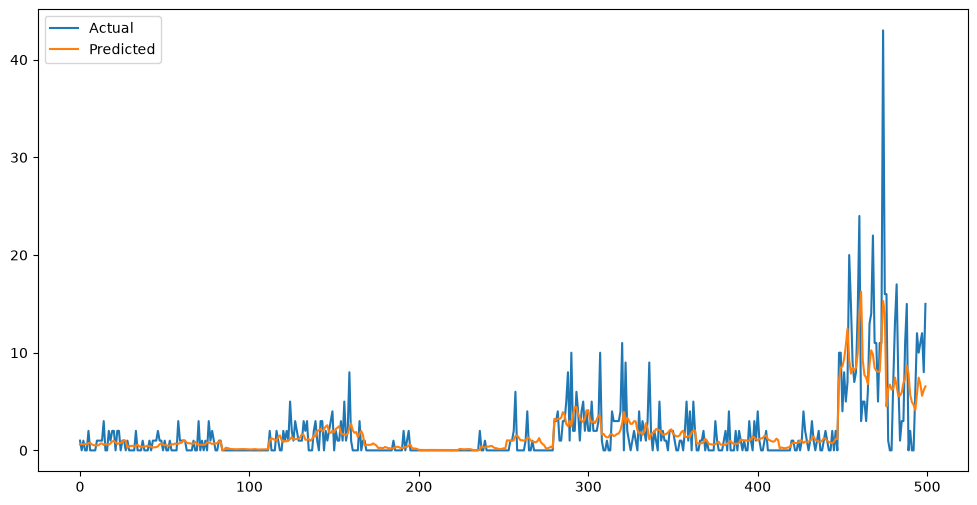

In [16]:
plt.figure(figsize=(12,6))

plt.plot(y_valid.values[:500], label="Actual")

plt.plot(valid_pred[:500], label="Predicted")

plt.legend()
plt.show()

In [23]:
# Save complete feature importance table

feature_importance.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

print("✓ Feature importance saved.")

✓ Feature importance saved.


In [24]:
# Save top 20 most important features

feature_importance.head(20).to_csv(
    "../outputs/top_20_features.csv",
    index=False
)

print("✓ Top 20 features saved.")

✓ Top 20 features saved.


In [25]:
validation_predictions = pd.DataFrame({
    "Actual": y_valid.values,
    "Predicted": valid_pred,
    "Residual": y_valid.values - valid_pred
})

validation_predictions.to_parquet(
    "../outputs/predictions/validation_predictions.parquet",
    index=False
)

print("✓ Validation predictions saved.")

✓ Validation predictions saved.


In [26]:
test_predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": test_pred,
    "Residual": y_test.values - test_pred
})

test_predictions.to_parquet(
    "../outputs/predictions/test_predictions.parquet",
    index=False
)

print("✓ Test predictions saved.")

✓ Test predictions saved.


In [27]:
metrics = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [mae],
    "RMSE": [rmse]
})

metrics.to_csv(
    "../outputs/xgboost_metrics.csv",
    index=False
)

print(metrics)

     Model       MAE      RMSE
0  XGBoost  0.973015  2.019652


In [28]:
parameters = pd.DataFrame(
    list(xgb.get_params().items()),
    columns=["Parameter", "Value"]
)

parameters.to_csv(
    "../outputs/xgboost_parameters.csv",
    index=False
)

print("✓ Model parameters saved.")

✓ Model parameters saved.


In [29]:
forecast = pd.DataFrame({
    "Actual": y_test.values,
    "Forecast": test_pred
})

forecast.to_parquet(
    "../outputs/predictions/final_forecast.parquet",
    index=False
)

print("✓ Forecast dataset saved.")

✓ Forecast dataset saved.


In [35]:
# Load baseline model results from Notebook 05

results = pd.read_csv("../outputs/model_comparison.csv")

xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [mae],
    "RMSE": [rmse]
})

xgb_results = xgb_results.round({
    "MAE": 3,
    "RMSE": 3
})

results = pd.concat(
    [results, xgb_results],
    ignore_index=True
)

results.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("✓ Model comparison saved.")

✓ Model comparison saved.


In [36]:
results["Rank"] = (
    results["RMSE"]
    .rank(method="dense")
    .astype(int)
)

results = (
    results
    .sort_values("Rank")
    .reset_index(drop=True)
)

results

,Model,MAE,RMSE,Rank
0,XGBoost,0.973015,2.019652,1
1,XGBoost,0.973000,2.020000,2
2,Random Forest,1.076000,2.523000,3
3,Moving Average,0.999000,2.638000,4
4,Linear Regression,1.071000,2.641000,5
5,Seasonal Naive,1.334000,3.850000,6
